In [ ]:
# Project 4: COVID-19 Trends Analysis (Healthcare Domain)

**Executive Summary**  
- Analyzed global COVID-19 data (2020–2022)  
- Total cases & deaths trends, peak waves  
- Key findings: Multiple waves (2020–2021), highest peaks in late 2021  
- Insights: Deaths lag cases by ~2 weeks; high correlation between cases and deaths  
- Recommendations: Strengthen healthcare capacity during waves, promote vaccination, monitor hospitalizations

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")

In [6]:
# Load global COVID data (large but clean)
url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
df = pd.read_csv(url)

# Convert date & filter global or India
df['date'] = pd.to_datetime(df['date'])
df_global = df[df['location'] == 'World'].copy()  # Global aggregate

print("Loaded! Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Date range (global):", df_global['date'].min().date(), "to", df_global['date'].max().date())
print(df_global.head(3))

Loaded! Shape: (429435, 67)
Columns: ['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_f

In [7]:
print("\n=== Data Quality (Global) ===")
print("Missing values in key columns:\n", df_global[['new_cases', 'new_deaths', 'total_cases', 'total_deaths']].isnull().sum())

# Fill missing new cases/deaths with 0 (common for early data)
df_global['new_cases'] = df_global['new_cases'].fillna(0)
df_global['new_deaths'] = df_global['new_deaths'].fillna(0)

print("\n=== Key Statistics (Global) ===")
print("Total cases:", df_global['total_cases'].max())
print("Total deaths:", df_global['total_deaths'].max())
print("Peak daily cases:", df_global['new_cases'].max())
print("Peak daily deaths:", df_global['new_deaths'].max())


=== Data Quality (Global) ===
Missing values in key columns:
 new_cases       10
new_deaths      10
total_cases     10
total_deaths    10
dtype: int64

=== Key Statistics (Global) ===
Total cases: 775866783.0
Total deaths: 7057132.0
Peak daily cases: 44236227.0
Peak daily deaths: 103719.0


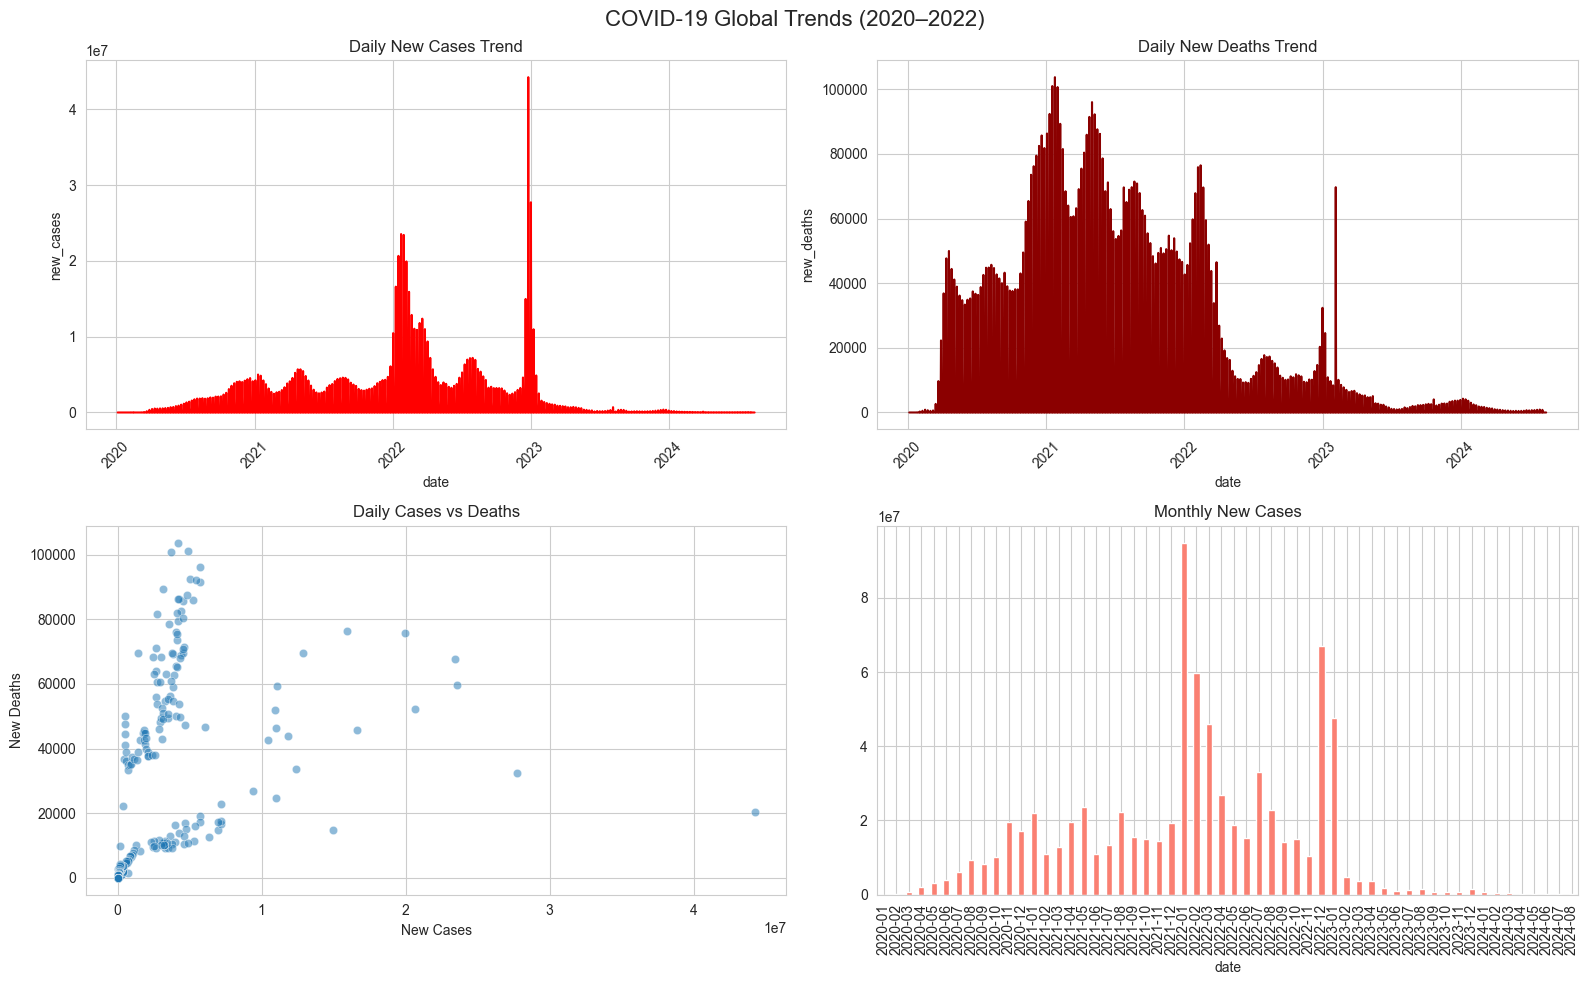

Visuals saved as 'covid_visuals.png'


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('COVID-19 Global Trends (2020–2022)', fontsize=16)

# 1. New Cases Trend (Line)
sns.lineplot(data=df_global, x='date', y='new_cases', color='red', ax=axes[0,0])
axes[0,0].set_title('Daily New Cases Trend')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. New Deaths Trend (Line)
sns.lineplot(data=df_global, x='date', y='new_deaths', color='darkred', ax=axes[0,1])
axes[0,1].set_title('Daily New Deaths Trend')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Cases vs Deaths Scatter (correlation)
sns.scatterplot(x='new_cases', y='new_deaths', data=df_global, alpha=0.5, ax=axes[1,0])
axes[1,0].set_title('Daily Cases vs Deaths')
axes[1,0].set_xlabel('New Cases')
axes[1,0].set_ylabel('New Deaths')

# 4. Monthly Total Cases (Bar)
monthly_cases = df_global.groupby(df_global['date'].dt.to_period('M'))['new_cases'].sum()
monthly_cases.plot(kind='bar', ax=axes[1,1], color='salmon')
axes[1,1].set_title('Monthly New Cases')
axes[1,1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

fig.savefig('covid_visuals.png', dpi=300, bbox_inches='tight')
print("Visuals saved as 'covid_visuals.png'")

In [9]:
print("\n=== Key Insights ===")
print("1. Highest daily cases peak:", df_global['new_cases'].max(), "on", df_global.loc[df_global['new_cases'].idxmax(), 'date'].date())
print("2. Highest daily deaths peak:", df_global['new_deaths'].max(), "on", df_global.loc[df_global['new_deaths'].idxmax(), 'date'].date())
print("3. Correlation between new cases and deaths:", round(df_global['new_cases'].corr(df_global['new_deaths']), 3))
print("4. Deaths lag cases (approx. 14–21 days)")

print("\n=== Actionable Recommendations ===")
print("• Strengthen ICU/hospital capacity during peak waves (e.g., late 2021)")
print("• Accelerate vaccination drives to flatten future curves")
print("• Monitor weekly trends as leading indicators for policy")
print("• Focus public health messaging on high-risk periods")


=== Key Insights ===
1. Highest daily cases peak: 44236227.0 on 2022-12-25
2. Highest daily deaths peak: 103719.0 on 2021-01-24
3. Correlation between new cases and deaths: 0.572
4. Deaths lag cases (approx. 14–21 days)

=== Actionable Recommendations ===
• Strengthen ICU/hospital capacity during peak waves (e.g., late 2021)
• Accelerate vaccination drives to flatten future curves
• Monitor weekly trends as leading indicators for policy
• Focus public health messaging on high-risk periods
